# 지니계수 및 로렌츠 곡선 (불평등도 분석)

### 1-1. 장르별 지니계수 계산

**분석**: 장르별 `daily_view_count`의 지니계수(불평등도)를 계산 — 값이 높을수록 그 장르 안에서 소수 곡이 조회수를 독점한다는 의미.

/tmp/ipython-input-1530280420.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_gini.index, y=genre_gini.values, palette='magma')


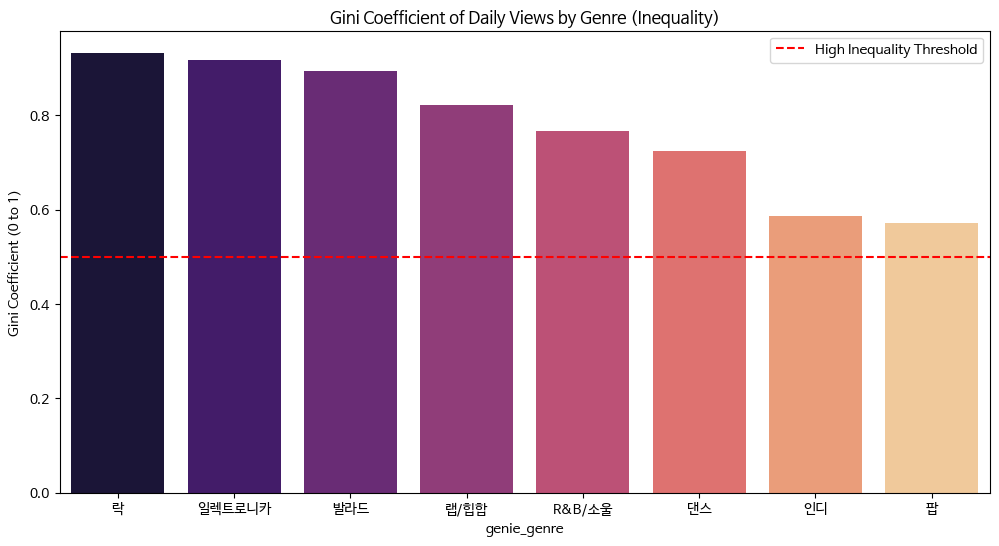

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_gini(x):
    # 지니계수 계산 함수
    sorted_x = np.sort(x)
    n = len(x)
    cum_x = np.cumsum(sorted_x)
    return (n + 1 - 2 * np.sum(cum_x) / cum_x[-1]) / n

# 장르별 지니계수 계산
genre_gini = 분석_df.groupby('genie_genre')['daily_view_count'].apply(get_gini).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_gini.index, y=genre_gini.values, palette='magma')
plt.title('Gini Coefficient of Daily Views by Genre (Inequality)')
plt.ylabel('Gini Coefficient (0 to 1)')
plt.axhline(0.5, color='red', linestyle='--', label='High Inequality Threshold')
plt.legend()
plt.show()

### 1-2. 지니계수 + 통계량 시각화

**분석**: 지니계수 계산 결과를 통계량과 함께 다시 시각화.

,gini_coefficient
count,8.000000
mean,0.776914
std,0.142003
min,0.572194
25%,0.689306
50%,0.794696
75%,0.900168
max,0.932661


,genie_genre,gini_coefficient
0,락,0.932661
1,일렉트로니카,0.916916
2,발라드,0.894585
3,랩/힙합,0.822452
4,R&B/소울,0.766939
5,댄스,0.723829
6,인디,0.585736
7,팝,0.572194


/tmp/ipython-input-1731894842.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


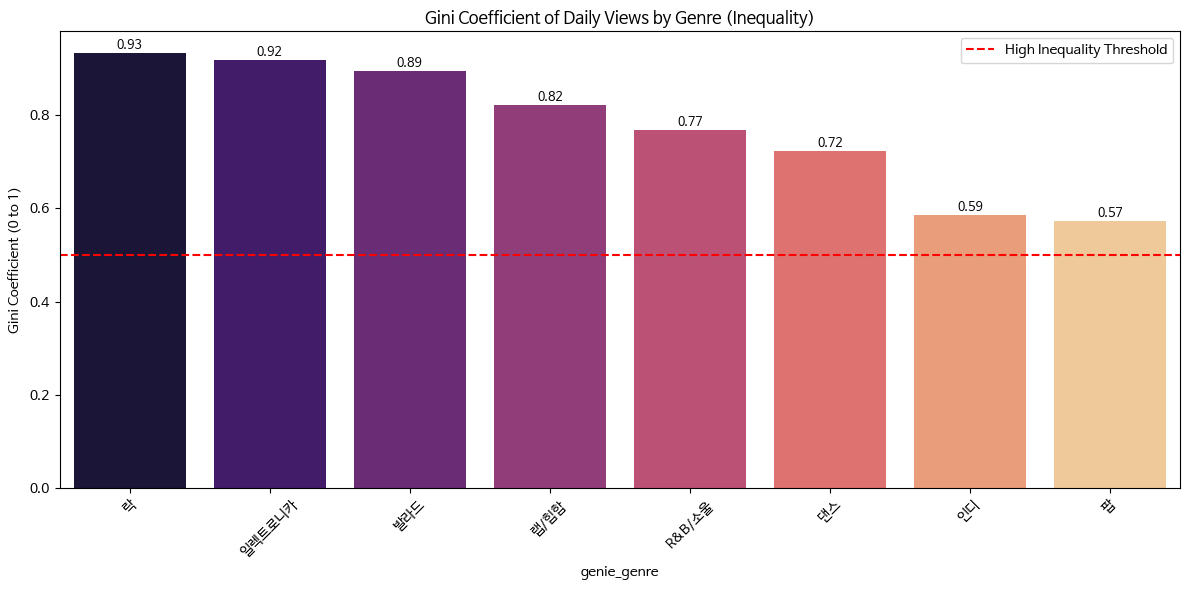

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_gini(x):
    sorted_x = np.sort(x)
    n = len(x)
    cum_x = np.cumsum(sorted_x)
    return (n + 1 - 2 * np.sum(cum_x) / cum_x[-1]) / n

# ─────────────────────────────
# 1️⃣ 장르별 지니계수 계산
# ─────────────────────────────
genre_gini = (
    분석_df
    .groupby('genie_genre')['daily_view_count']
    .apply(get_gini)
    .sort_values(ascending=False)
)

# 👉 통계 테이블로 보기
gini_df = genre_gini.reset_index()
gini_df.columns = ['genie_genre', 'gini_coefficient']

display(gini_df.describe())   # 전체 분포 통계
display(gini_df)              # 장르별 지니계수 표

# ─────────────────────────────
# 2️⃣ 시각화 + 숫자 라벨
# ─────────────────────────────
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=genre_gini.index,
    y=genre_gini.values,
    palette='magma'
)

plt.title('Gini Coefficient of Daily Views by Genre (Inequality)')
plt.ylabel('Gini Coefficient (0 to 1)')
plt.axhline(0.5, color='red', linestyle='--', label='High Inequality Threshold')
plt.legend()

# 👉 막대 위에 숫자 표시
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 1-3. 로렌츠 곡선

**분석**: 장르별 로렌츠 곡선(누적 곡 비율×누적 조회수 비율)으로 조회수 쏠림 정도를 시각화.
**결과**: 락은 지니계수가 높아 상위 20% 곡이 조회수 대부분을 독점(곡선이 깊게 휨), 팝은 상대적으로 완만함 → 장르마다 '대박'이 나오는 방식(소수 곡 의존 vs 고른 분포)이 다르다는 해석.

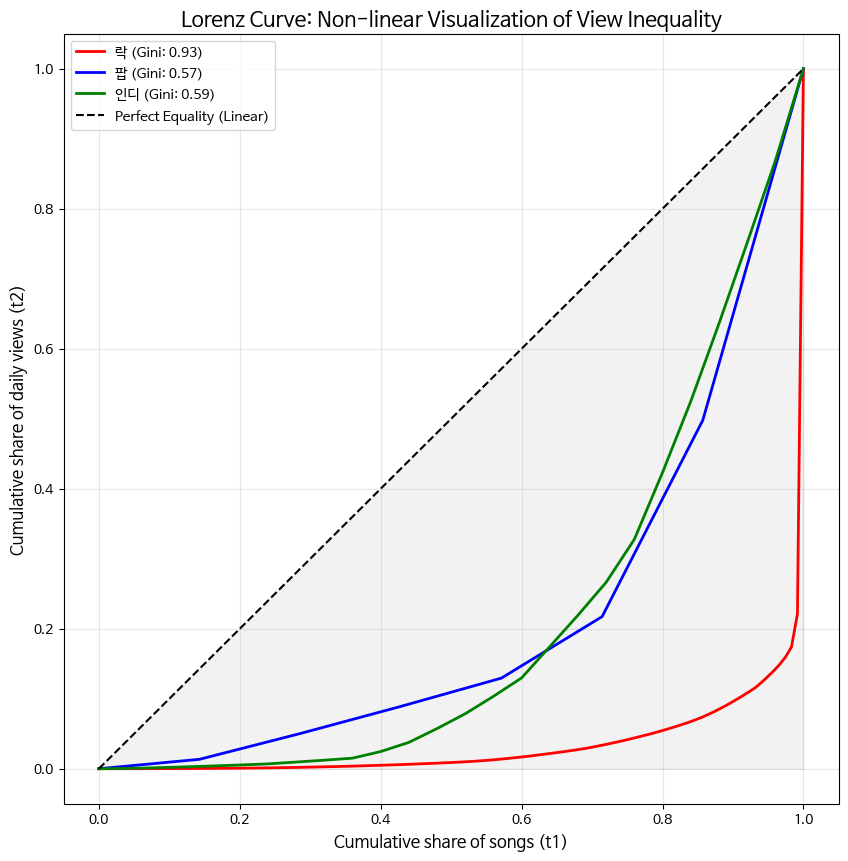

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fancy_lorenz(df, genre_name, color):
    # 1. 해당 장르의 조회수만 추출하여 정렬
    v = df[df['genie_genre'] == genre_name]['daily_view_count'].values
    v_sorted = np.sort(v)

    # 2. 가로축(t1): 곡의 누적 비율 (0 to 1)
    # 3. 세로축(t2): 조회수의 누적 합 비율 (0 to 1)
    t1 = np.linspace(0, 1, len(v_sorted) + 1)
    t2 = np.insert(np.cumsum(v_sorted) / np.sum(v_sorted), 0, 0)

    # 그래프 그리기
    plt.plot(t1, t2, label=f'{genre_name} (Gini: {get_gini(v):.2f})', color=color, lw=2)
    return t1, t2

# 시각화 설정
plt.figure(figsize=(10, 10))

# 비교할 장르 선택 (지니계수 최고 vs 최저)
genres_to_show = [('락', 'red'), ('팝', 'blue'), ('인디', 'green')]

for genre, color in genres_to_show:
    plot_fancy_lorenz(분석_df, genre, color)

# 대각선 (완전 평등선)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Perfect Equality (Linear)')

# 채우기 (선택 사항: 곡선과 직선 사이의 면적이 넓을수록 불평등)
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')

plt.title('Lorenz Curve: Non-linear Visualization of View Inequality', fontsize=15)
plt.xlabel('Cumulative share of songs (t1)', fontsize=12)
plt.ylabel('Cumulative share of daily views (t2)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1-4. 로렌츠 곡선 3D 함수 정의

**진행 내용**: 로렌츠 곡선에 세 번째 축(예: energy)을 추가한 3D 버전 함수를 정의.

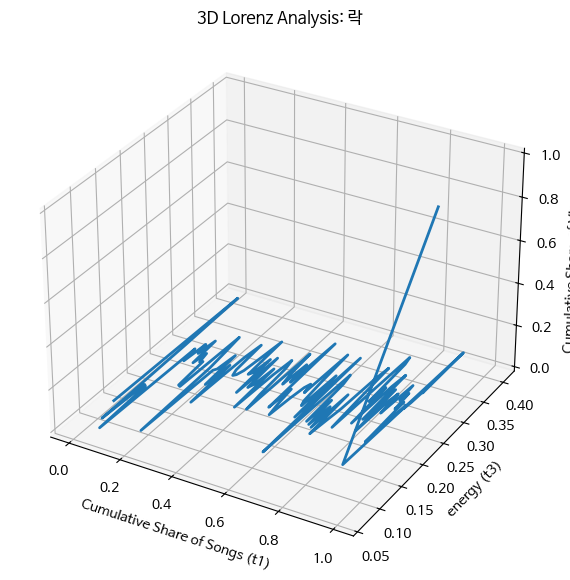

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_lorenz(df, genre_name, z_var):
    genre_df = df[df['genie_genre'] == genre_name].sort_values('daily_view_count')

    t1 = np.linspace(0, 1, len(genre_df)) # 곡의 비율
    t2 = np.cumsum(genre_df['daily_view_count']) / genre_df['daily_view_count'].sum() # 조회수 누적
    t3 = genre_df[z_var].values # 비교하고 싶은 변수 (예: energy)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(t1, t3, t2, label=f'{genre_name} Lorenz Curve', lw=2)

    ax.set_xlabel('Cumulative Share of Songs (t1)')
    ax.set_ylabel(f'{z_var} (t3)')
    ax.set_zlabel('Cumulative Share of Views (t2)')
    plt.title(f'3D Lorenz Analysis: {genre_name}')
    plt.show()

# '락' 장르의 에너지 변수로 3D 분석 실행
plot_3d_lorenz(분석_df, '락', 'energy')

### 1-5. 팝 장르 로렌츠 분석 (2D/3D)

**분석**: 팝 장르에 2D/3D 로렌츠 곡선을 적용해 락과 비교(곡선의 휘어짐 정도 확인).

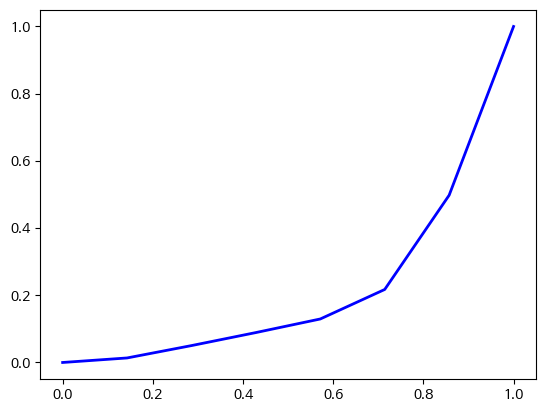

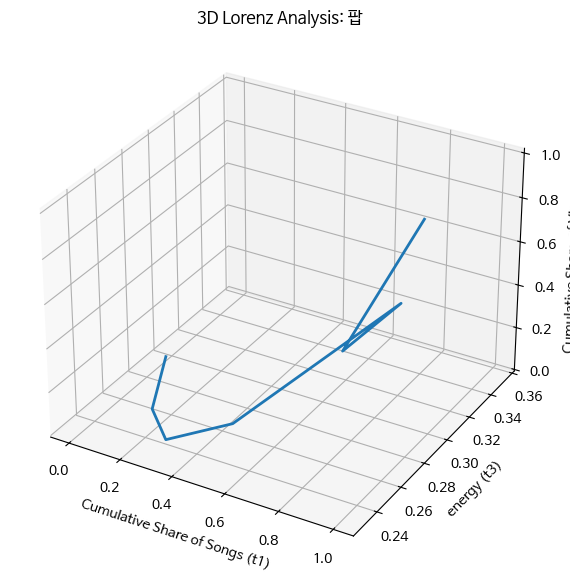

In [ ]:
# 1. 팝 장르 2D 로렌츠 곡선 (t1, t2)
plot_fancy_lorenz(분석_df, '팝', 'blue')

# 2. 팝 장르 3D 로렌츠 분석 (t1, t2, t3: energy)
# 락과 비교했을 때 곡선의 휘어짐이나 솟구치는 정도가 훨씬 완만할 것입니다.
plot_3d_lorenz(분석_df, '팝', 'energy')

### 1-6. 전체 장르 로렌츠 곡선 비교

**분석**: 모든 장르의 2D 로렌츠 곡선을 한 그래프에 겹쳐서 비교.

/tmp/ipython-input-2507557725.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(genres))


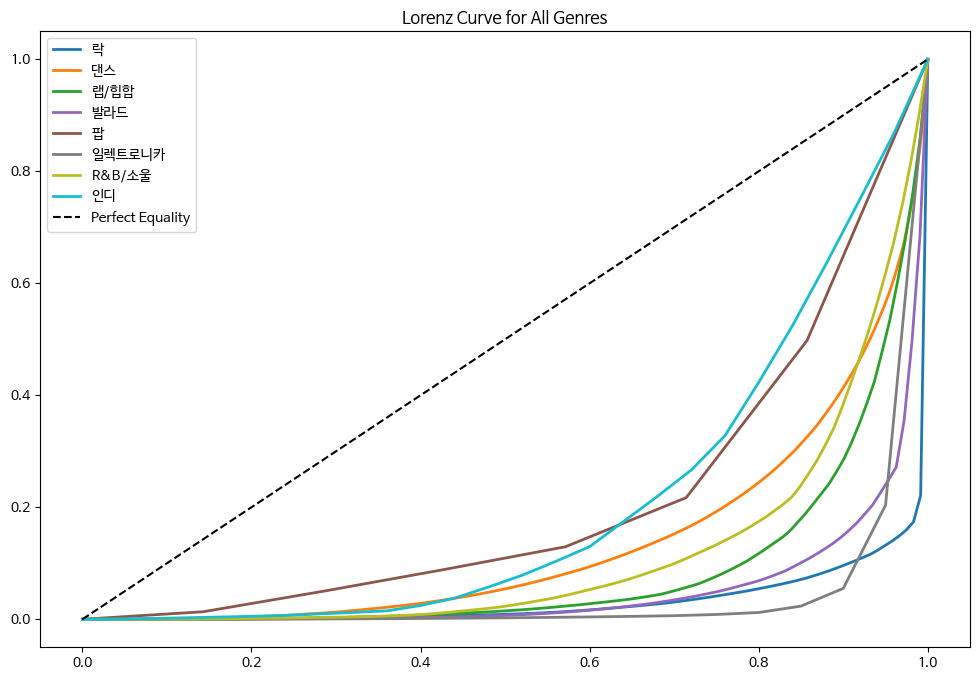

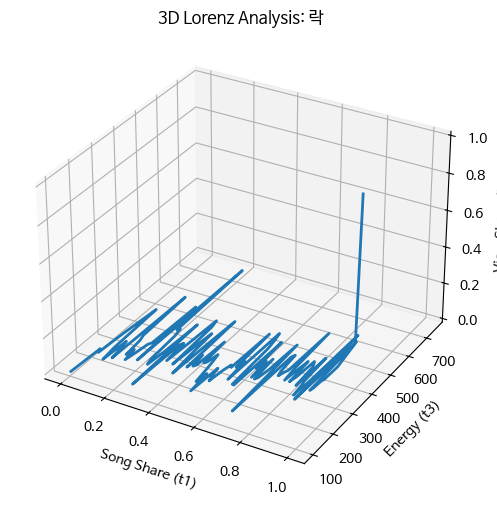

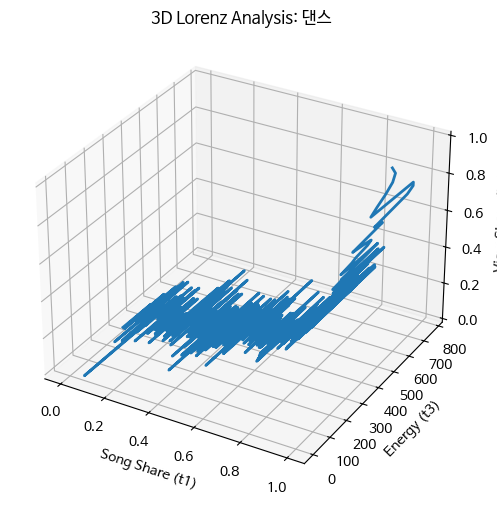

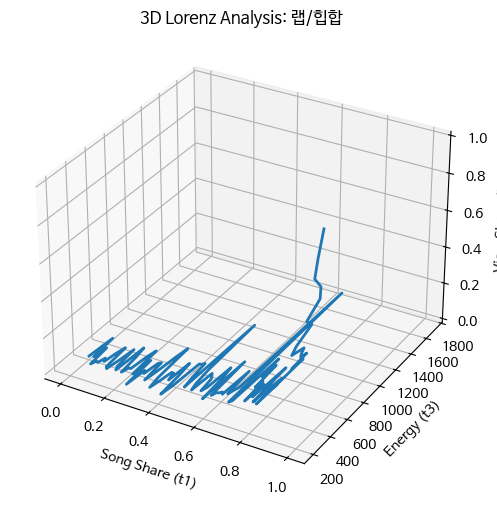

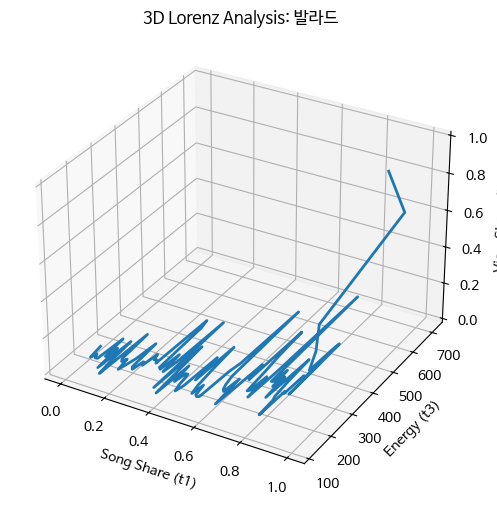

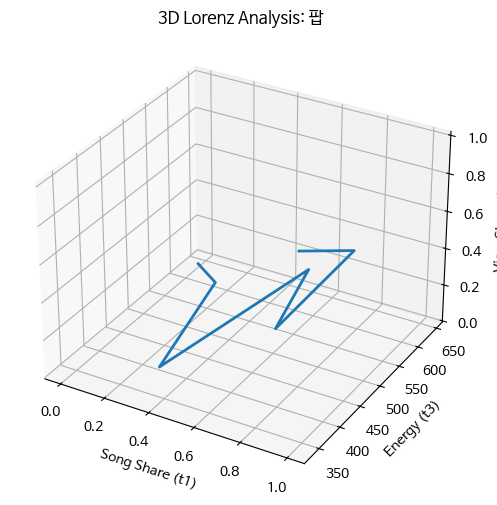

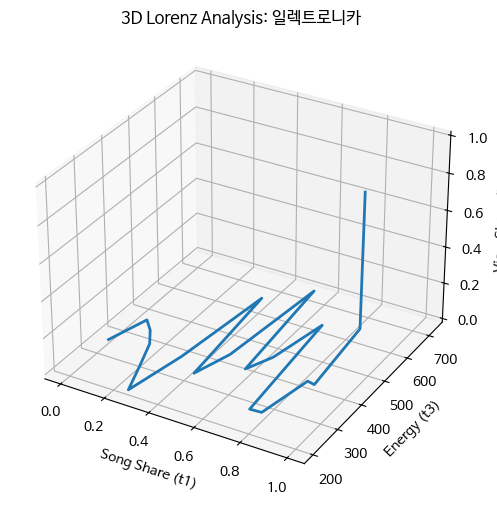

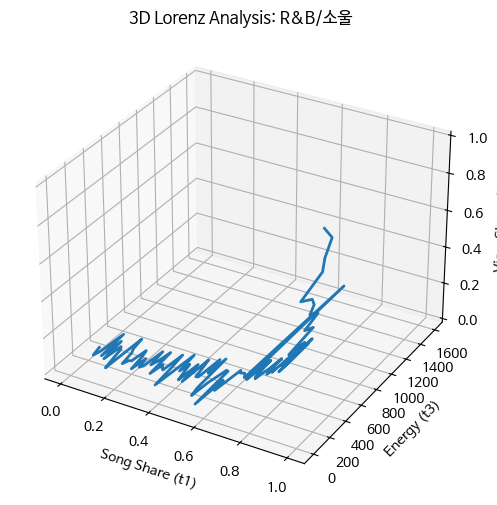

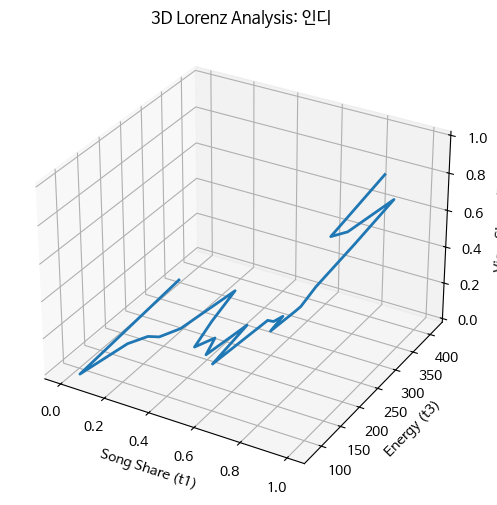

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

genres = 분석_df['genie_genre'].unique()
colors = plt.cm.get_cmap('tab10', len(genres))

# 1. 모든 장르 2D 로렌츠 곡선 비교
plt.figure(figsize=(12, 8))
for i, genre in enumerate(genres):
    v = 분석_df[분석_df['genie_genre'] == genre]['daily_view_count'].values
    v_sorted = np.sort(v)
    t1 = np.linspace(0, 1, len(v_sorted) + 1)
    t2 = np.insert(np.cumsum(v_sorted) / np.sum(v_sorted), 0, 0)
    plt.plot(t1, t2, label=f'{genre}', color=colors(i), lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect Equality')
plt.title('Lorenz Curve for All Genres')
plt.legend()
plt.show()

# 2. 모든 장르 3D 로렌츠 분석 (장르별 개별 그래프 출력)
for genre in genres:
    genre_df = 분석_df[분석_df['genie_genre'] == genre].sort_values('daily_view_count')
    t1 = np.linspace(0, 1, len(genre_df))
    t2 = np.cumsum(genre_df['daily_view_count']) / genre_df['daily_view_count'].sum()
    t3 = genre_df['token_count'].values # 세 번째 축으로 'energy' 사용

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(t1, t3, t2, lw=2)
    ax.set_title(f'3D Lorenz Analysis: {genre}')
    ax.set_xlabel('Song Share (t1)')
    ax.set_ylabel('Energy (t3)')
    ax.set_zlabel('View Share (t2)')
    plt.show()

### 1-7. 락 vs 팝 핵심 변수 산점도

**분석**: 지니계수가 극단적으로 다른 두 장르(락 vs 팝)의 valence·arousal·acoustic_score 산점도를 비교(로그 스케일 조회수).

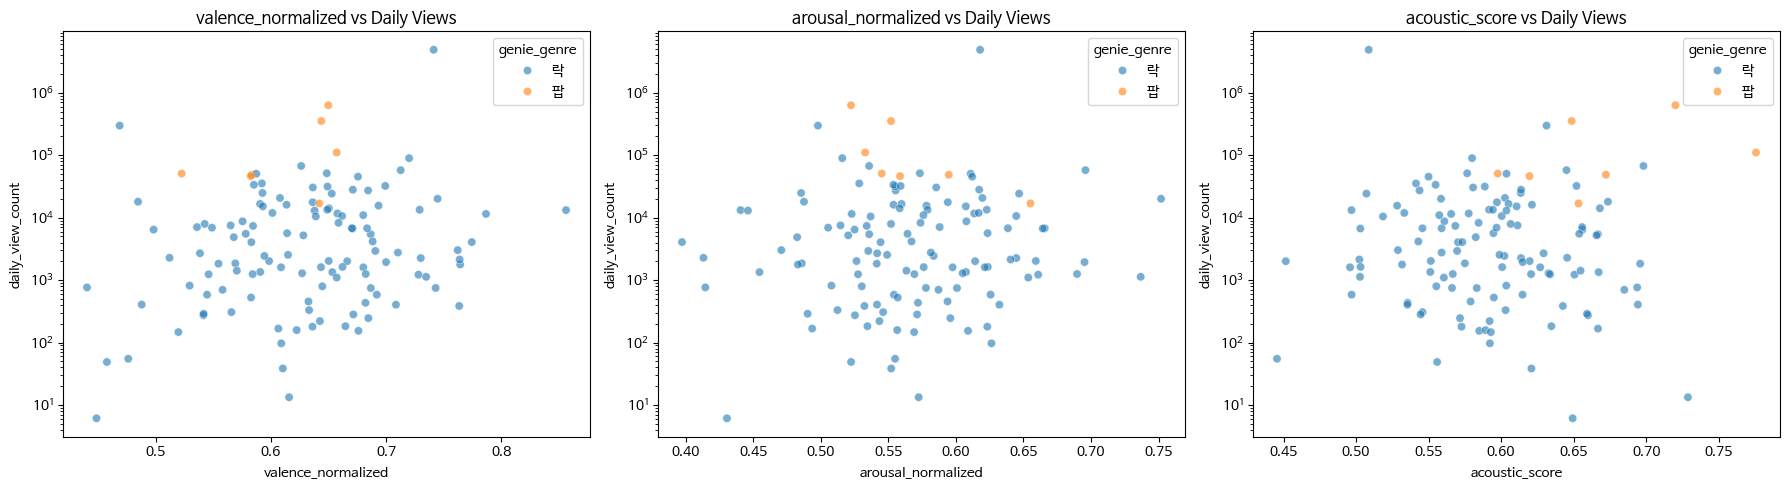

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


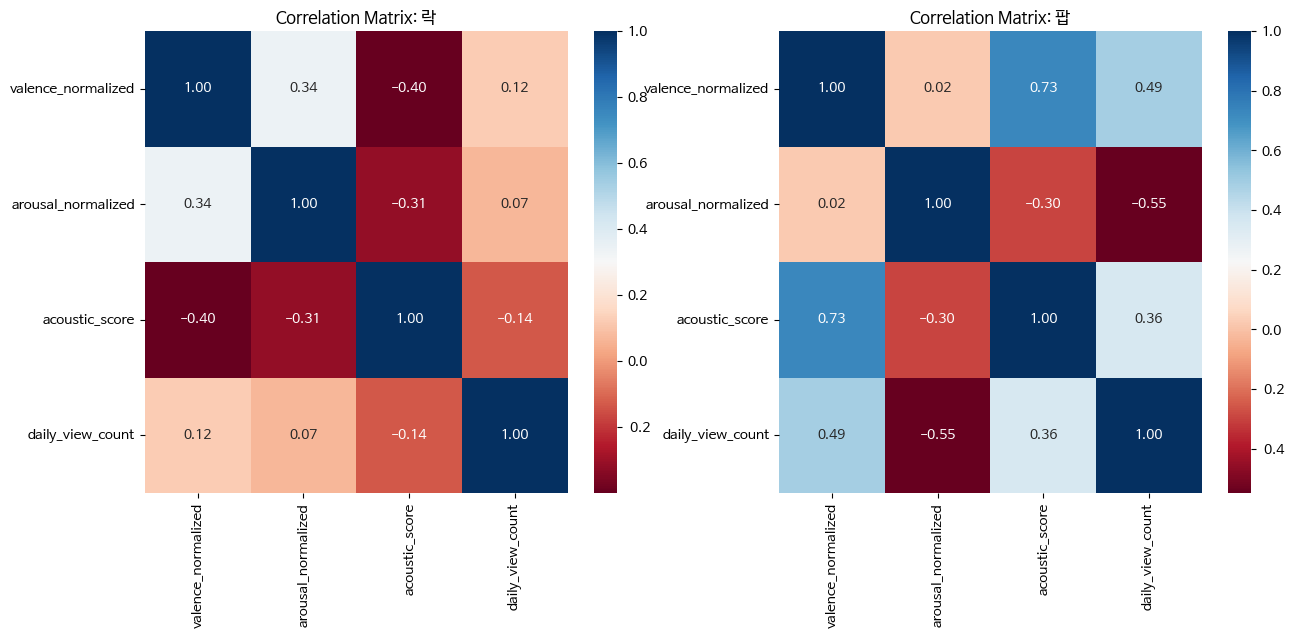

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 지니계수 극단적 두 장르 비교 대상 설정
compare_genres = ['락', '팝']
analysis_vars = ['valence_normalized', 'arousal_normalized', 'acoustic_score']

# 2. 산점도(Scatter Plot) 시각화
# 조회수(daily_view_count)의 편차가 크므로 로그 스케일을 적용해 분포를 더 명확히 봅니다.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(analysis_vars):
    sns.scatterplot(data=분석_df[분석_df['genie_genre'].isin(compare_genres)],
                    x=var, y='daily_view_count',
                    hue='genie_genre', alpha=0.6, ax=axes[i])
    axes[i].set_yscale('log') # y축 로그 스케일
    axes[i].set_title(f'{var} vs Daily Views')

plt.tight_layout()
plt.show()

# 3. 장르별 상관계수 히트맵 비교
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, genre in enumerate(compare_genres):
    genre_data = 분석_df[분석_df['genie_genre'] == genre][analysis_vars + ['daily_view_count']]
    sns.heatmap(genre_data.corr(), annot=True, cmap='RdBu', fmt=".2f", ax=axes[i])
    axes[i].set_title(f'Correlation Matrix: {genre}')

plt.show()